# Delta策略模块演示

这个notebook演示如何使用delta模块进行策略研究和回测。

In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import sys
sys.path.append('/home/jovyan/base_demo')
import base_tool

import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

## 导入delta模块

In [3]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')
from delta import *

## 设置参数（包含自适应参数）

In [6]:
instrument_id = '511090'
trade_ymd = '20260319'
train_preset = 'volatility_16d'  # 可选: 'recent_6d', 'volatility_8d', 'volatility_12d', 'volatility_16d'
y_window = 600
k = 3
param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': f'delta_v1_adaptive_{train_preset}',
    'stride': 1,

    'short_window': 300,
    'long_window': 600,
    'y_window': y_window,

    'open_threshold': 3,  
    'open_confidence': 0,  

    'standard_num': 1000,

    'atr_multiplier': 4,
    'vol_window': 600,
    
    'k_up': k,
    'k_down': k,
    'adverse_cusum_threshold': 10,
    'adverse_cusum_drift': 3,

    "stop_tighten_start": 6000,
    'stop_tighten_step' : 60,
    'stop_tighten_factor': 0.9,
    'stop_tighten_floor': 0.75,
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

## 获取交易日数据

In [7]:
trade_dates = get_trade_dates()
print(f"总交易日数量: {len(trade_dates)}")
print(f"交易日范围: {trade_dates[0]} ~ {trade_dates[-1]}")

# 使用严格按时间顺序的切分，并显式留出 embargo 区间。
train_candidate_dates, valid_dates, test_dates, embargo_dates = split_dates_with_embargo(
    trade_dates,
    train_start="20250901",
    train_end="20251231",
    valid_start="20260101",
    valid_end="20260215",
    embargo_start="20260217",
    embargo_end="20260231",
    test_start="20260301",
    test_end="20260425",
)

train_dates = select_train_dates_by_preset(
    train_preset,
    train_candidate_dates,
    instrument_id=instrument_id,
)
validate_date_splits(train_dates, valid_dates, test_dates, embargo_dates)

print(f"当前训练方案: {train_preset}")
print(f"最终训练天数: {len(train_dates)}")
print("训练日期列表:", train_dates)
print("验证日期列表:", valid_dates)
print("Embargo日期列表:", embargo_dates)
print("测试日期列表:", test_dates)


总交易日数量: 79
交易日范围: 20250901 ~ 20260423
训练集: 20250901 ~ 20251231 (42天)
验证集: 20260105 ~ 20260213 (15天)
Embargo: 20260225 ~ 20260227 (2天)
测试集: 20260303 ~ 20260423 (20天)
当前训练方案: volatility_16d
最终训练天数: 16
训练日期列表: ['20250901', '20250915', '20250917', '20250919', '20250925', '20250929', '20251013', '20251017', '20251021', '20251029', '20251103', '20251105', '20251107', '20251209', '20251217', '20251229']
验证日期列表: ['20260105', '20260107', '20260109', '20260113', '20260115', '20260119', '20260121', '20260123', '20260127', '20260129', '20260203', '20260205', '20260209', '20260211', '20260213']
Embargo日期列表: ['20260225', '20260227']
测试日期列表: ['20260303', '20260305', '20260309', '20260311', '20260313', '20260317', '20260319', '20260323', '20260325', '20260327', '20260331', '20260401', '20260403', '20260407', '20260409', '20260413', '20260415', '20260417', '20260421', '20260423']


## 生成训练数据

In [8]:
all_dates = sorted(set(train_dates) | set(valid_dates) | set(test_dates))
sample_cache = load_daily_sample_cache(
    all_dates,
    instrument_id,
    param_dict,
    create_feature,
    create_y,
)

X_train, y_train, feature_names = concat_sample_cache(sample_cache, train_dates)
X_valid, y_valid, _ = concat_sample_cache(sample_cache, valid_dates)
X_test, y_test, _ = concat_sample_cache(sample_cache, test_dates)

print(f"训练集样本: X={X_train.shape}, y={y_train.shape}")
print(f"验证集样本: X={X_valid.shape}, y={y_valid.shape}")
print(f"测试集样本: X={X_test.shape}, y={y_test.shape}")


20250901: 产生 274 个样本
20250915: 产生 270 个样本
20250917: 产生 249 个样本
20250919: 产生 275 个样本
20250925: 产生 286 个样本
20250929: 产生 276 个样本
20251013: 产生 230 个样本
20251017: 产生 240 个样本
20251021: 产生 296 个样本
20251029: 产生 284 个样本
20251103: 产生 288 个样本
20251105: 产生 282 个样本
20251107: 产生 275 个样本
20251209: 产生 292 个样本
20251217: 产生 292 个样本
20251229: 产生 261 个样本
20260105: 产生 308 个样本
20260107: 产生 286 个样本
20260109: 产生 275 个样本
20260113: 产生 273 个样本
20260115: 产生 305 个样本
20260119: 产生 324 个样本
20260121: 产生 268 个样本
20260123: 产生 285 个样本
20260127: 产生 303 个样本
20260129: 产生 327 个样本
20260203: 产生 319 个样本
20260205: 产生 345 个样本
20260209: 产生 340 个样本
20260211: 产生 346 个样本
20260213: 产生 310 个样本
20260303: 产生 331 个样本
20260305: 产生 363 个样本
20260309: 产生 316 个样本
20260311: 产生 331 个样本
20260313: 产生 333 个样本
20260317: 产生 339 个样本
20260319: 产生 307 个样本
20260323: 产生 321 个样本
20260325: 产生 369 个样本
20260327: 产生 375 个样本
20260331: 产生 342 个样本
20260401: 产生 356 个样本
20260403: 产生 364 个样本
20260407: 产生 330 个样本
20260409: 产生 379 个样本
20260413: 产生 357 个样本
20260415: 产生 

## 训练模型

In [9]:
print(f"开始训练，方案: {train_preset}")
model = train_model(X_train, y_train, X_valid, y_valid, param_dict , feature_names)

开始训练，方案: volatility_16d
训练 xgboost 模型...
[0]	validation_0-logloss:0.69266


[100]	validation_0-logloss:0.67742
[200]	validation_0-logloss:0.67127
[300]	validation_0-logloss:0.66612
[400]	validation_0-logloss:0.66272
[500]	validation_0-logloss:0.65894
[600]	validation_0-logloss:0.65848
[700]	validation_0-logloss:0.65591
[800]	validation_0-logloss:0.65346
[900]	validation_0-logloss:0.65199
[999]	validation_0-logloss:0.65066
阈值优化完成: Best Threshold=0.4964, F0.5=0.4489

特征重要性（前10个）:
volatility               0.229008
alpha_07                 0.109593
alpha_09                 0.100014
MPC                      0.099598
positive_return_count    0.099506
alpha_08                 0.095523
alpha_06                 0.095117
RPP                      0.086970
alpha_03                 0.084670
dtype: float32

XGBoost特征重要性详情:

Gain重要性排名:
                 feature       gain
0             volatility  20.991564
3               alpha_07  10.045605
8               alpha_09   9.167602
6                    MPC   9.129418
7  positive_return_count   9.121019
5               alpha_08   

In [10]:
# 保存模型
model_path = f"/home/jovyan/work/model/delta_{instrument_id}_{train_preset}_{y_window}_{k}.pkl"
import joblib
joblib.dump(model, model_path)
print(f"模型已保存到: {model_path}")

模型已保存到: /home/jovyan/work/model/delta_511090_volatility_16d_600_3.pkl


## 测试模型

测试集准确率: 0.6079

分类报告:
              precision    recall  f1-score   support

           0       0.83      0.56      0.67      4833
           1       0.40      0.72      0.52      1949

    accuracy                           0.61      6782
   macro avg       0.62      0.64      0.59      6782
weighted avg       0.71      0.61      0.63      6782

在独立测试集上评估模型...
测试集准确率: 0.6454

分类报告:
              precision    recall  f1-score   support

           0       0.81      0.66      0.73      4833
           1       0.42      0.60      0.49      1949

    accuracy                           0.65      6782
   macro avg       0.61      0.63      0.61      6782
weighted avg       0.69      0.65      0.66      6782


PR曲线AUC: 0.4149
平均精度 (AP): 0.4153

预测概率统计:
  均值: 0.4547
  标准差: 0.1361
  最小值: 0.0197
  25%分位数: 0.3521
  中位数: 0.4530
  75%分位数: 0.5676
  最大值: 0.8289

按真实标签分组的预测概率统计:
  标签0 (负类): 均值=0.4314, 标准差=0.1360
  标签1 (正类): 均值=0.5126, 标准差=0.1181


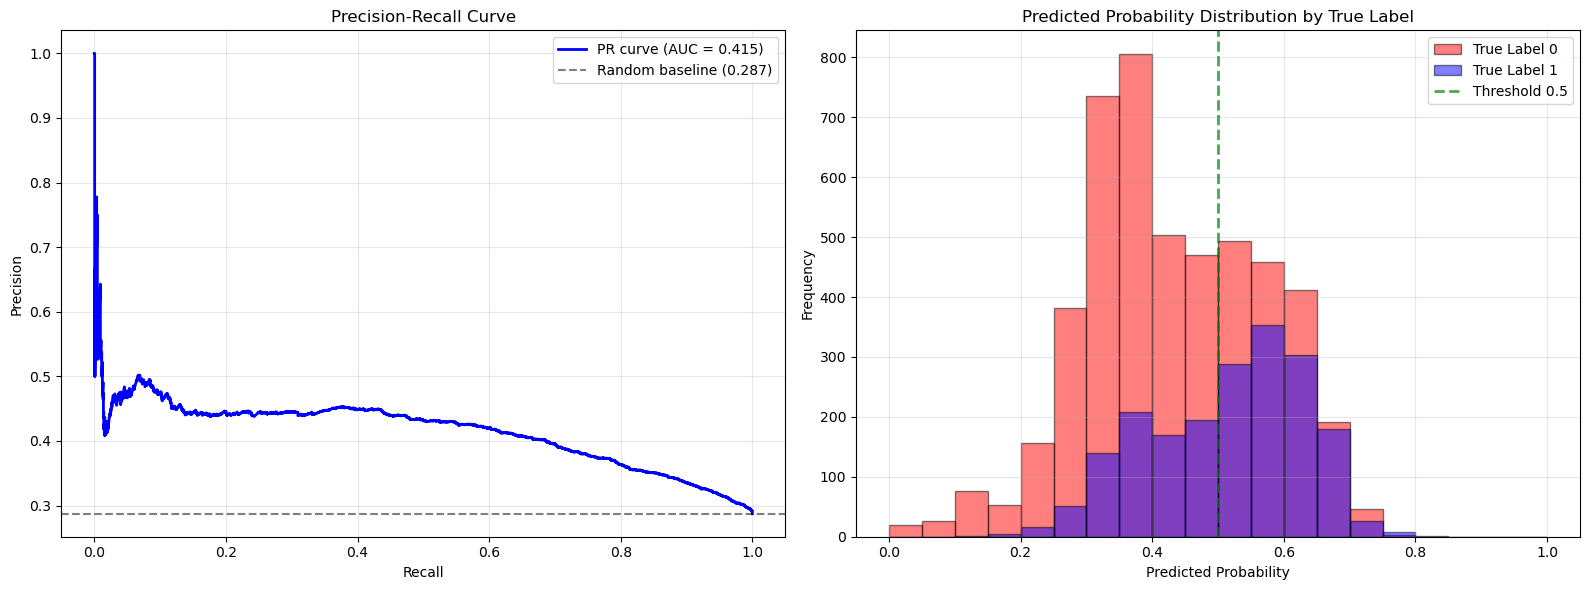

In [11]:
print("在独立测试集上评估模型...")
accuracy = evaluate_model(model, X_test, y_test, show_plots=True)


## 创建策略实例

In [12]:
model_path = f"/home/jovyan/work/model/delta_{instrument_id}_{train_preset}_{y_window}_{k}.pkl"
strategy = StrategyDemo(model_path, param_dict)
print(f"策略已创建: {strategy.name}")



策略已创建: delta_v1_adaptive_volatility_16d


## 使用backtesting工具进行回测

-> Python解释器: /opt/conda/bin/python
-> Python版本: 3.13.11 | packaged by conda-forge | (main, Jan 26 2026, 23:57:06) [GCC 14.3.0]
spawn模式启动
-> 当前 Python 解释器: /opt/conda/bin/python
-> 从delta/train.py获取到 79 个有数据的交易日
-> 过滤后剩余 39 个有数据的交易日
-> 过滤掉 77 个无数据日期: ['20251230', '20260101', '20260102', '20260103', '20260104', '20260106', '20260108', '20260110', '20260111', '20260112']...
-> 回测标的: 511090 (20251229 - 20260423)
-> 任务分配: 共 39 天，使用 4 个核心并行计算...


[SpawnPoolWorker-3] 日期 20260401 完成 | 盈亏: -13.90 | 成交: 16次 | 胜率: 25.0% | 平均持仓: 575.7快照
[SpawnPoolWorker-4] 日期 20260305 完成 | 盈亏: 9.60 | 成交: 13次 | 胜率: 53.9% | 平均持仓: 893.5快照
[SpawnPoolWorker-2] 日期 20260127 完成 | 盈亏: 1.80 | 成交: 15次 | 胜率: 40.0% | 平均持仓: 606.5快照
[SpawnPoolWorker-1] 日期 20251229 完成 | 盈亏: 6.60 | 成交: 13次 | 胜率: 38.5% | 平均持仓: 666.9快照
[SpawnPoolWorker-3] 日期 20260403 完成 | 盈亏: 29.70 | 成交: 12次 | 胜率: 33.3% | 平均持仓: 695.4快照
[SpawnPoolWorker-4] 日期 20260309 完成 | 盈亏: -16.70 | 成交: 10次 | 胜率: 30.0% | 平均持仓: 524.3快照
[SpawnPoolWorker-2] 日期 20260129 完成 | 盈亏: 11.00 | 成交: 14次 | 胜率: 50.0% | 平均持仓: 707.3快照
[SpawnPoolWorker-1] 日期 20251231 完成 | 盈亏: 18.20 | 成交: 14次 | 胜率: 35.7% | 平均持仓: 682.6快照
[SpawnPoolWorker-3] 日期 20260407 完成 | 盈亏: -10.40 | 成交: 14次 | 胜率: 21.4% | 平均持仓: 690.6快照
[SpawnPoolWorker-4] 日期 20260311 完成 | 盈亏: 6.70 | 成交: 12次 | 胜率: 50.0% | 平均持仓: 948.3快照
[SpawnPoolWorker-2] 日期 20260203 完成 | 盈亏: -3.00 | 成交: 12次 | 胜率: 33.3% | 平均持仓: 616.1快照
[SpawnPoolWorker-1] 日期 20260105 完成 | 盈亏: 6.90 | 成交: 12次 | 胜率: 66.7

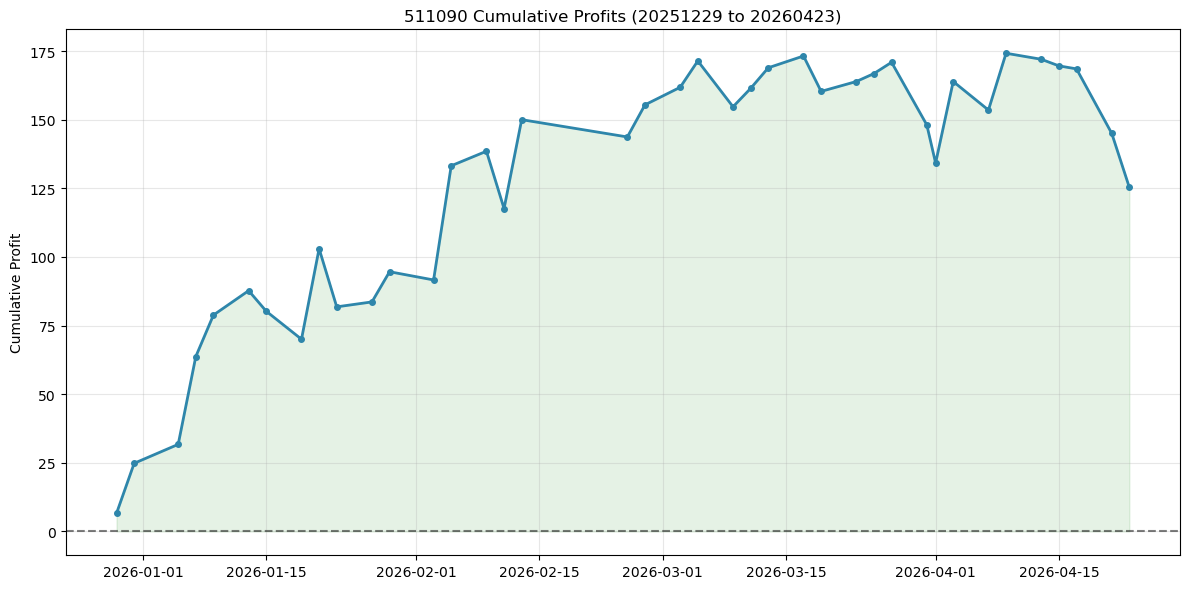


测试区间并行回测结果汇总:
{'测试天数': 39, '累计总盈亏': np.float64(125.3), '总成交次数': 520, '盈利交易次数': 197, '亏损交易次数': 323, '加权每手胜率%': np.float64(37.88), '日均盈亏': np.float64(3.21), '胜率(天)%': 58.97, '盈亏比(日均)': np.float64(1.14), '最大单日盈利': 41.6, '最大单日亏损': -23.5, '每笔交易平均盈利': np.float64(0.24), '加权平均持仓时间(快照)': np.float64(683.0)}


In [13]:
# 导入修复的并行回测模块
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_simple import run_parallel_backtest
from multi_day_backtest import backtest_summary

# 仅在测试区间上做并行回测，避免把训练期结果混进汇总。
result_df = run_parallel_backtest(
    instrument_id=instrument_id,
    start_ymd=train_dates[-1],
    end_ymd=test_dates[-1],
    StrategyClass=StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    n_cores=4,
)

print("\n测试区间并行回测结果汇总:")
summary = backtest_summary(result_df)
print(summary)


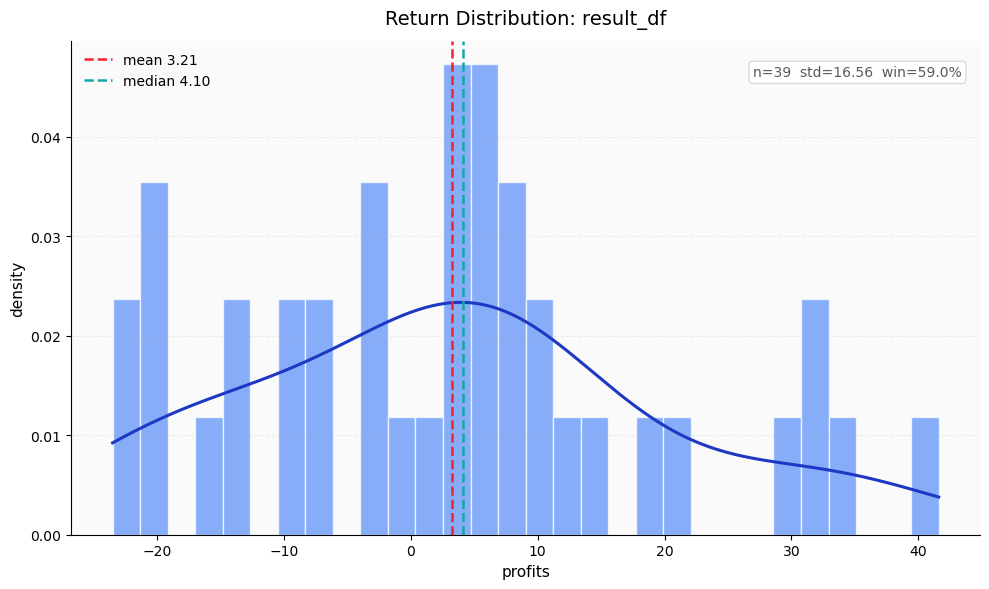

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Return Distribution: result_df'}, xlabel='profits', ylabel='density'>,
 {'count': 39,
  'mean': 3.212820512820512,
  'median': 4.1,
  'std': 16.56327865279379,
  'min': -23.5,
  'max': 41.6,
  'positive_ratio': 0.5897435897435898})

In [14]:
from tools import plot_return_distribution


plot_return_distribution(result_df = result_df)

## 延迟回测结果

In [ ]:
from delay_stability_test import batch_delay_stability_test
batch_delay_stability_test(
    instrument_id,
    test_dates[0],
    test_dates[-1],
    StrategyDemo,
    model_path,
    param_dict,
    [0,1,2,4,8,16,32,64,128,256,512,1024],
)


## 保存回测结果

In [26]:
# 导入结果保存工具
from tools.result_saver import save_backtest_results

# 保存回测结果

result_dir = save_backtest_results(
    param_dict=param_dict,
    summary=summary,
    result_df=result_df
)

print(f"回测结果已保存到: {result_dir}")
print("文件夹包含以下文件:")
import os
for file in os.listdir(result_dir):
    print(f"  - {file}")

保存回测结果到: /home/jovyan/work/tactics_demo/backtest_result/511090_delta_v1_adaptive_volatility_16d_20260428_121111
回测结果已保存到: /home/jovyan/work/tactics_demo/backtest_result/511090_delta_v1_adaptive_volatility_16d_20260428_121111
文件夹包含以下文件:
  - summary.json
  - daily_results.pkl
  - parameters.json
  - daily_results.csv
  - README.md


In [362]:
from tools import delete_backtest_results_by_date, delete_backtest_results_by_instrument_date
delete_backtest_results_by_date("20260413", dry_run=True)
deleted = delete_backtest_results_by_instrument_date("511520", "20260420", dry_run=False)


[DRY RUN] 总共将删除 0 个文件夹
已删除: /home/jovyan/work/tactics_demo/backtest_result/511520_delta_v1_adaptive_20260420_062243

总共删除了 1 个文件夹


## 单日回测观察

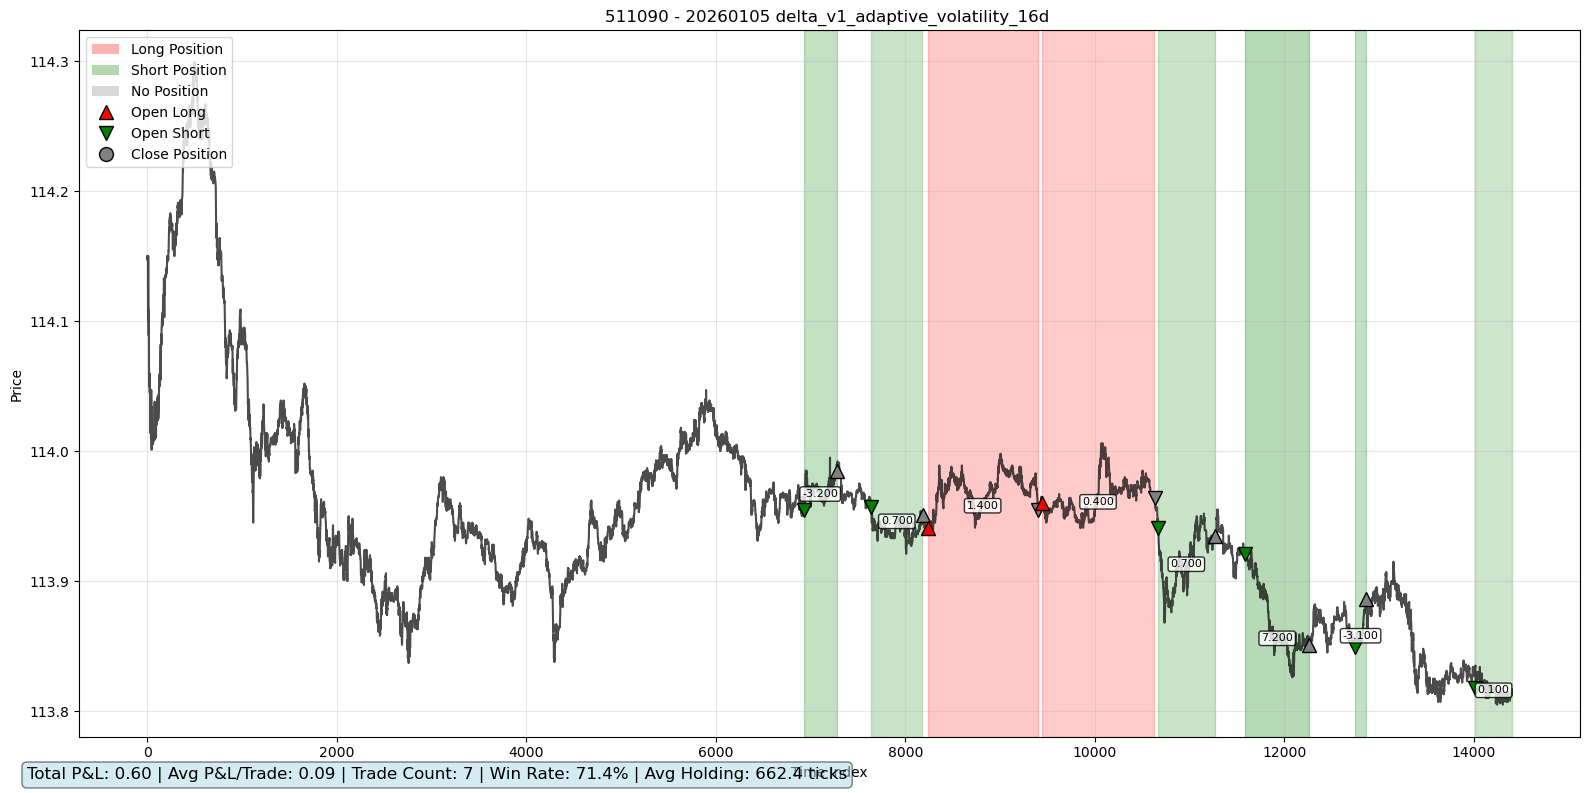

In [159]:
from single_day_backtest import single_day_backtest,plot_delta_history

hh = single_day_backtest(instrument_id,'20260105',StrategyDemo,model_path,param_dict,official = False)

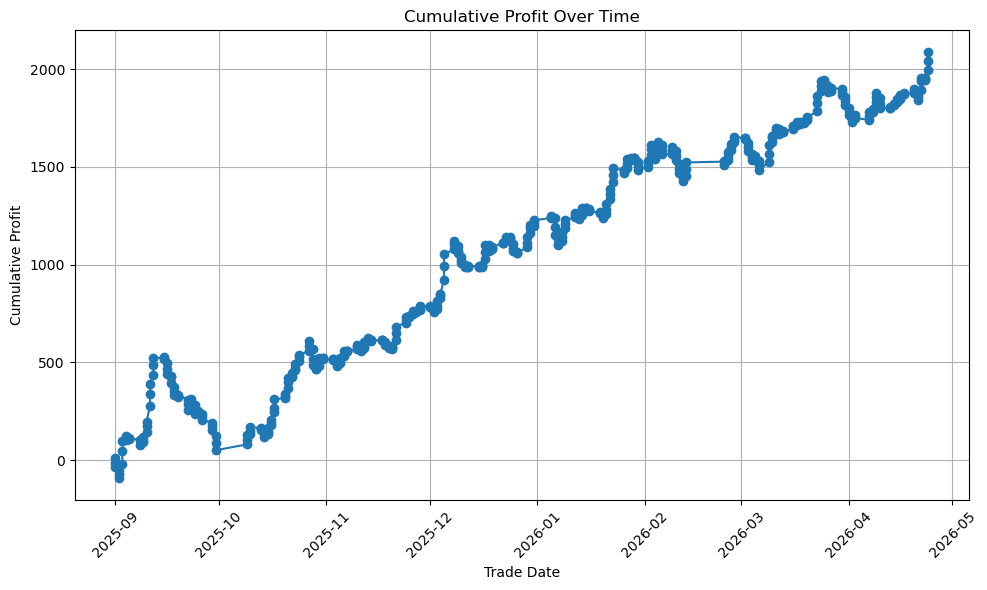

In [5]:
summary = pd.read_csv('/home/jovyan/work/live_trading/511090_20260428_oyyb_03.csv')
# plot cumulative profits

summary['cumulative_profit'] = summary['profits'].cumsum()
summary['trade_ymd'] = pd.to_datetime(summary['trade_ymd'], format='%Y%m%d')
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(summary['trade_ymd'], summary['cumulative_profit'], marker='o')
plt.title('Cumulative Profit Over Time')
plt.xlabel('Trade Date')
plt.ylabel('Cumulative Profit')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()
